# Bài Toán VQA v2 (Visual Question Answering)
## Mô hình Baseline 1: Pretrained CNN + BiLSTM (Không dùng Attention)



---
### Bước 1: Cài đặt các thư viện nền tảng
Chúng ta cần cài đặt các thư viện cốt lõi với phiên bản tương thích để tránh lỗi trong quá trình thực thi:
- `torch`, `torchvision`: Framework Deep Learning chính dùng để xây dựng các mạng Nơ-ron (CNN, RNN) và xử lý ảnh.
- `torchtext`: Thư viện chuyên biệt hỗ trợ xử lý ngôn ngữ tự nhiên (NLP) và xây dựng từ điển (Vocabulary).

In [1]:
# Cài đặt phiên bản torch và torchtext tương thích
!pip install torch==2.3.1 torchvision==0.18.1 torchtext==0.18.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 803.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176

### Bước 2: Import Thư viện và Khởi tạo Môi trường
- **Import các module:** Tải các thư viện toán học (`numpy`), vẽ biểu đồ (`matplotlib`), xử lý ảnh (`PIL`, `timm`) và công cụ quản lý dữ liệu của PyTorch (`Dataset`, `DataLoader`).
- **Khởi tạo Spacy:** Load bộ xử lý ngữ pháp tiếng Anh `en_core_web_sm`. Công cụ này đóng vai trò "cắt" câu hỏi và câu trả lời thành từng từ đơn lẻ (tokenization).
- **Cố định Seed (Reproducibility):** Hàm `set_seed(59)` cố định các yếu tố ngẫu nhiên (như chia batch, khởi tạo trọng số). Việc này đảm bảo kết quả huấn luyện sẽ nhất quán nếu bạn chạy lại nhiều lần.
- **Thiết lập Device:** Kiểm tra và ưu tiên kích hoạt GPU (`cuda`) để tăng tốc xử lý ma trận.

In [2]:
import torchtext
torchtext.disable_torchtext_deprecation_warning()
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import os
import random
import json
import numpy as np
import spacy
import timm
import shutil
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchtext.vocab import build_vocab_from_iterator
from tqdm.auto import tqdm

# Khởi tạo spacy
try:
    eng = spacy.load("en_core_web_sm")
except:
    import os
    os.system("python -m spacy download en_core_web_sm")
    eng = spacy.load("en_core_web_sm")

def set_seed(seed=59):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: cuda


### Bước 3: Tải Dữ liệu Hình ảnh và Nhãn
Bài toán VQA v2 sử dụng bộ ảnh MS COCO và các câu hỏi/trả lời đi kèm:
- Câu lệnh `wget` tải trực tiếp dữ liệu hình ảnh (Val 2014) và file Annotations (Chứa câu hỏi, đáp án) vào thẳng ổ cứng ảo của Google Colab.
- Việc lưu trữ trực tiếp trên Colab (`/content/`) giúp tốc độ đọc ảnh khi training nhanh hơn gấp nhiều lần so với việc đọc từ Google Drive.
*(Lưu ý: Quá trình tải ~6GB dữ liệu có thể tốn một vài phút).*

In [3]:
# Tạo thư mục
os.makedirs('/content/VQA_v2/Images', exist_ok=True)
os.makedirs('/content/VQA_v2/Text', exist_ok=True)

print("1. Đang tải Ảnh COCO Val 2014 (~6GB)...")
!wget -c -q http://images.cocodataset.org/zips/val2014.zip -P /content/VQA_v2/Images/

print("2. Đang tải Câu hỏi & Câu trả lời VQA v2...")
!wget -c -q https://s3.amazonaws.com/cvmlp/vqa/mscoco/vqa/v2_Questions_Val_mscoco.zip -P /content/VQA_v2/Text/
!wget -c -q https://s3.amazonaws.com/cvmlp/vqa/mscoco/vqa/v2_Annotations_Val_mscoco.zip -P /content/VQA_v2/Text/

print("3. Đang giải nén dữ liệu...")
!unzip -q -n /content/VQA_v2/Images/val2014.zip -d /content/VQA_v2/Images/
!unzip -q -n /content/VQA_v2/Text/v2_Questions_Val_mscoco.zip -d /content/VQA_v2/Text/
!unzip -q -n /content/VQA_v2/Text/v2_Annotations_Val_mscoco.zip -d /content/VQA_v2/Text/

print("Hoàn tất tải và giải nén!")


1. Đang tải Ảnh COCO Val 2014 (~6GB)...
2. Đang tải Câu hỏi & Câu trả lời VQA v2...
3. Đang giải nén dữ liệu...
Hoàn tất tải và giải nén!


### Bước 4: Khai phá và Đồng bộ dữ liệu (Data Parsing)
Hàm `load_vqa_v2_data` có nhiệm vụ kết nối hình ảnh với các câu hỏi tương ứng:
1. Đọc 2 file JSON: File câu hỏi (Questions) và File đáp án (Annotations).
2. Dùng Dictionary để map siêu tốc `question_id` với đáp án đúng (multiple_choice_answer).
3. Gom bộ 3 thông tin: **Đường dẫn ảnh**, **Câu hỏi** và **Câu trả lời** vào một danh sách.
4. Trộn ngẫu nhiên (Shuffle) và chia tập dữ liệu thành 2 phần:
   - **Tập Train (80%):** Dữ liệu để mô hình học tập.
   - **Tập Validation (20%):** Bài kiểm tra để đánh giá năng lực của mô hình (Mô hình chưa từng nhìn thấy các ảnh/câu hỏi này lúc train).

Đang đọc file JSON...


Đang xử lý dữ liệu:   0%|          | 0/214354 [00:00<?, ?it/s]

Số lượng Train: 24000 | Val: 6000
ĐANG TRÍCH XUẤT DỮ LIỆU ĐỂ XEM THỬ...


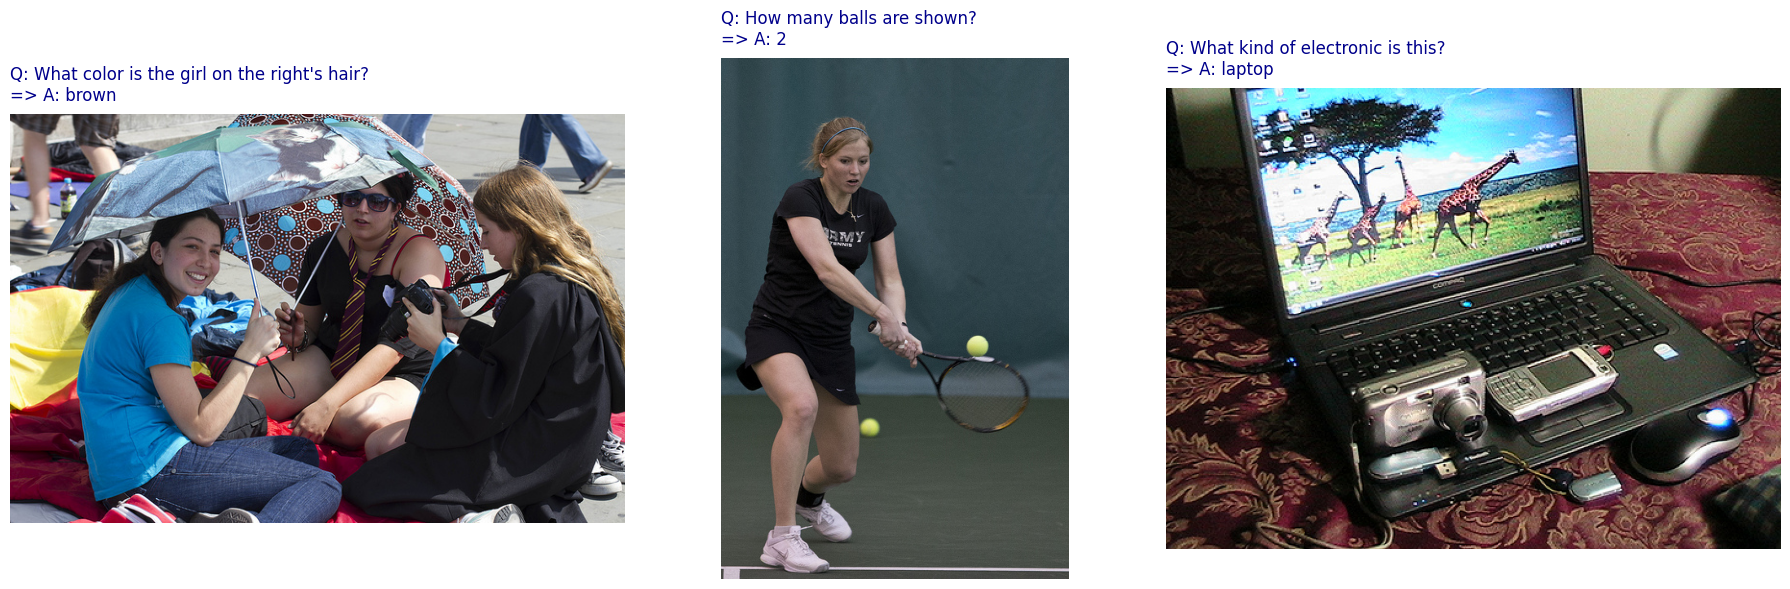

In [4]:
def load_vqa_v2_data(questions_path, annotations_path, max_samples=None):
    print("Đang đọc file JSON...")
    with open(questions_path, 'r') as f:
        qs = json.load(f)['questions']
    with open(annotations_path, 'r') as f:
        anns = json.load(f)['annotations']

    # Tạo dictionary để map nhanh câu trả lời vào câu hỏi
    ann_dict = {ann['question_id']: ann['multiple_choice_answer'] for ann in anns}

    data = []
    for q in tqdm(qs, desc="Đang xử lý dữ liệu"):
        q_id = q['question_id']
        img_id = q['image_id']

        img_filename = f"COCO_val2014_{img_id:012d}.jpg"

        data.append({
            'image_path': img_filename,
            'question': q['question'],
            'answer': ann_dict[q_id]
        })

    random.shuffle(data)

    if max_samples:
        data = data[:max_samples]

    return data

Q_PATH = '/content/VQA_v2/Text/v2_OpenEnded_mscoco_val2014_questions.json'
A_PATH = '/content/VQA_v2/Text/v2_mscoco_val2014_annotations.json'

all_data = load_vqa_v2_data(Q_PATH, A_PATH, max_samples=30000)

# Chia Train / Val theo tỉ lệ 80/20
split_idx = int(len(all_data) * 0.8)
train_data = all_data[:split_idx]
val_data = all_data[split_idx:]

print(f"Số lượng Train: {len(train_data)} | Val: {len(val_data)}")

def show_random_samples(data_list, img_dir, num_samples=3):
    """Hàm hiển thị ngẫu nhiên các mẫu dữ liệu VQA"""

    samples = random.sample(data_list, num_samples)

    fig, axes = plt.subplots(1, num_samples, figsize=(18, 6))

    for i, sample in enumerate(samples):
        img_path = os.path.join(img_dir, sample['image_path'])
        question = sample['question']
        answer = sample['answer']

        try:
            img = Image.open(img_path).convert('RGB')
            axes[i].imshow(img)
        except Exception as e:
            axes[i].text(0.5, 0.5, 'Lỗi đọc ảnh', ha='center')

        axes[i].axis('off')

        title = f"Q: {question}\n=> A: {answer}"
        axes[i].set_title(title, fontsize=12, color='darkblue', pad=10, loc='left')

    plt.tight_layout()
    plt.show()

IMG_DIR = '/content/VQA_v2/Images/val2014/'
print("ĐANG TRÍCH XUẤT DỮ LIỆU ĐỂ XEM THỬ...")
show_random_samples(train_data, IMG_DIR, num_samples=3)

### Bước 5: Phân mảnh từ vựng (Tokenization) & Pipeline Dữ liệu



1. **Xây dựng Từ điển (Vocabulary):**
   - Quét qua toàn bộ tập Train, lọc các từ xuất hiện từ 2 lần trở lên để cho vào từ điển.
   - Định nghĩa 4 Thẻ đặc biệt (Special Tokens): `<pad>` (đệm cho bằng chiều dài), `<sos>` (Bắt đầu câu), `<eos>` (Kết thúc câu), và `<unk>` (Từ lạ không có trong từ điển).
2. **Class `VQADataset`:** Lớp này chuẩn bị dữ liệu cho AI:
   - Load ảnh và chuẩn hóa kích thước về `224x224` (chuẩn của mạng ResNet).
   - Biến câu hỏi thành chuỗi ID số và đệm thẻ `<pad>`.
   - Biến câu trả lời thành chuỗi ID số, kẹp giữa `<sos>` và `<eos>`.
3. **Dataloader:** Đóng gói dữ liệu thành từng lô (Batch = 64) để đẩy vào GPU xử lý song song.

In [5]:
# 1. Xây dựng Vocab
def yield_tokens(data_iter):
    for sample in data_iter:
        yield [token.text for token in eng.tokenizer(sample['question'])]
        yield [token.text for token in eng.tokenizer(sample['answer'])]

PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3
special_symbols = ['<pad>', '<sos>', '<eos>', '<unk>']

print("Đang xây dựng bộ từ vựng...")
vocab = build_vocab_from_iterator(
    yield_tokens(train_data),
    min_freq=2,
    specials=special_symbols,
    special_first=True
)
vocab.set_default_index(UNK_IDX)
print(f"Kích thước bộ từ vựng: {len(vocab)} từ")

# 2. Định nghĩa Dataset
class VQASeq2SeqDataset(Dataset):
    def __init__(self, data, vocab, max_q_len=20, max_a_len=5, transform=None, img_dir=''):
        self.data = data
        self.vocab = vocab
        self.max_q_len = max_q_len
        self.max_a_len = max_a_len
        self.transform = transform
        self.img_dir = img_dir

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        sample = self.data[index]

        # Xử lý Ảnh
        img_path = os.path.join(self.img_dir, sample['image_path'])
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)

        # Xử lý Câu hỏi
        q_tokens = [token.text for token in eng.tokenizer(sample['question'])]
        q_indices = [self.vocab[t] for t in q_tokens][:self.max_q_len]
        q_indices += [self.vocab['<pad>']] * (self.max_q_len - len(q_indices))

        # Xử lý Câu trả lời (Seq2Seq: thêm <sos> và <eos>)
        a_tokens = [token.text for token in eng.tokenizer(sample['answer'])]
        a_indices = [self.vocab['<sos>']] + [self.vocab[t] for t in a_tokens] + [self.vocab['<eos>']]
        a_indices = a_indices[:self.max_a_len]
        a_indices += [self.vocab['<pad>']] * (self.max_a_len - len(a_indices))

        return img, torch.tensor(q_indices, dtype=torch.long), torch.tensor(a_indices, dtype=torch.long)

# 3. Tạo DataLoader
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

IMG_DIR = '/content/VQA_v2/Images/val2014/'

train_dataset = VQASeq2SeqDataset(train_data, vocab, transform=transform, img_dir=IMG_DIR)
val_dataset = VQASeq2SeqDataset(val_data, vocab, transform=transform, img_dir=IMG_DIR)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=0)

Đang xây dựng bộ từ vựng...
Kích thước bộ từ vựng: 3607 từ


### Bước 6: Định nghĩa Kiến trúc Seq2Seq (Encoder - Decoder Không Attention)



**1. Khai báo Class `VQA_EncoderDecoder`:**
- **Image Encoder:** Dùng mạng `ResNet18` nén toàn bộ bức ảnh thành một vector duy nhất `[512]`. Do không dùng Attention, mô hình buộc phải "nhớ" toàn bộ khung cảnh thay vì chú ý vào từng vật thể nhỏ.
- **Question Encoder:** Dùng mạng `BiLSTM` (LSTM 2 chiều) mã hóa câu hỏi, sau đó ghép nối đặc trưng 2 chiều thành vector `[1024]`.
- **Fusion:** Gộp vector Ảnh và Câu hỏi lại rồi nén về Context Vector (`h_dec`).
- **Decoder & Scheduled Sampling:** Đây là cơ chế cốt lõi. Trong lúc huấn luyện, hàm sẽ gieo xúc xắc (`teacher_forcing_ratio=0.5`). 50% cơ hội AI được "mớm" đáp án chuẩn để đoán từ tiếp theo, 50% cơ hội nó phải dùng từ do chính nó vừa đoán ra. Điều này giúp AI tự học cách sửa sai và chống hiện tượng Lệch phơi nhiễm (Exposure Bias).

**2. Hàm Đánh giá (`evaluate_seq2seq`):**
Mô phỏng bài thi thực tế. Thiết lập `teacher_forcing_ratio = 0.0` để cắt hoàn toàn quyền trợ giúp. Mô hình phải tự sinh ra đáp án từ con số 0.

In [6]:
class VQA_EncoderDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_size=512, drop_p=0.4):
        super(VQA_EncoderDecoder, self).__init__()

        self.img_encoder = timm.create_model('resnet18', pretrained=True, num_classes=hidden_size)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.q_lstm = nn.LSTM(embed_dim, hidden_size, batch_first=True, bidirectional=True)
        self.fc_context = nn.Linear(hidden_size * 3, hidden_size)

        self.dec_lstm = nn.LSTM(embed_dim, hidden_size, batch_first=True)
        self.fc_out = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(drop_p)

    def forward(self, img, question, answer_input=None, max_gen_len=5, sos_idx=1, teacher_forcing_ratio=0.5):
        # 1. Xử lý Ảnh
        img_feat = self.img_encoder(img)

        # 2. Xử lý Câu hỏi
        q_emb = self.dropout(self.embedding(question))
        _, (h_n, _) = self.q_lstm(q_emb)
        q_feat = torch.cat((h_n[0], h_n[1]), dim=1)

        # 3. Tạo Context Vector
        combined = torch.cat((img_feat, q_feat), dim=1)
        h_dec = torch.relu(self.fc_context(self.dropout(combined))).unsqueeze(0)
        c_dec = torch.zeros_like(h_dec)

        # 4. Quá trình DECODING chung bằng vòng lặp (Scheduled Sampling)
        batch_size = img.size(0)
        device = img.device

        # Ký tự đầu tiên luôn là <SOS>
        curr_token = torch.full((batch_size, 1), sos_idx, dtype=torch.long, device=device)
        outputs = []

        # Độ dài sinh chuỗi (Theo target lúc train, theo max_gen_len lúc test)
        gen_len = answer_input.size(1) if answer_input is not None else max_gen_len

        for t in range(gen_len):
            emb = self.dropout(self.embedding(curr_token))
            out, (h_dec, c_dec) = self.dec_lstm(emb, (h_dec, c_dec))
            vocab_logits = self.fc_out(out)
            outputs.append(vocab_logits)

            # Lấy từ có xác suất cao nhất tại bước t
            top1 = vocab_logits.argmax(dim=-1)

            # Gieo xúc xắc xem có mớm bài (Teacher Forcing) hay để mô hình tự bơi
            if answer_input is not None and random.random() < teacher_forcing_ratio:
                curr_token = answer_input[:, t:t+1]
            else:
                curr_token = top1

        return torch.cat(outputs, dim=1)

def evaluate_seq2seq(model, dataloader, criterion, device, vocab):
    model.eval()
    total_loss, correct_tokens, total_tokens = 0, 0, 0
    pad_idx = vocab['<pad>']
    sos_idx = vocab['<sos>']

    with torch.no_grad():
        for imgs, questions, answers in tqdm(dataloader, desc="Validating", leave=False):
            imgs, questions, answers = imgs.to(device), questions.to(device), answers.to(device)

            # Target để tính Loss và Acc là bỏ từ <sos> đầu tiên
            ans_target = answers[:, 1:]
            max_len = ans_target.shape[1]

            # SỬA LỖI DATA LEAKAGE: Truyền answer_input = None để model tự sinh, không mớm nhãn
            logits = model(imgs, questions, answer_input=None, max_gen_len=max_len, sos_idx=sos_idx, teacher_forcing_ratio=0.0)

            loss = criterion(logits.reshape(-1, logits.size(-1)), ans_target.reshape(-1))
            total_loss += loss.item()

            preds = logits.argmax(dim=-1)
            mask = ans_target != pad_idx
            correct_tokens += ((preds == ans_target) & mask).sum().item()
            total_tokens += mask.sum().item()

    return total_loss / len(dataloader), correct_tokens / total_tokens if total_tokens > 0 else 0

def fit_seq2seq(model, train_loader, val_loader, optimizer, epochs, device, vocab):
    criterion = nn.CrossEntropyLoss(ignore_index=vocab['<pad>'])
    master_bar = tqdm(range(epochs), desc="Tổng tiến trình")
    train_losses, val_losses, val_accuracies = [], [], []

    for epoch in master_bar:
        model.train()
        train_loss = 0
        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}', leave=True)

        for imgs, questions, answers in progress_bar:
            imgs, questions, answers = imgs.to(device), questions.to(device), answers.to(device)

            # Training vẫn giữ ans_input để Teacher Forcing hội tụ nhanh
            ans_input, ans_target = answers[:, :-1], answers[:, 1:]

            optimizer.zero_grad()
            logits = model(imgs, questions, answer_input=ans_input, teacher_forcing_ratio=0.5)
            loss = criterion(logits.reshape(-1, logits.size(-1)), ans_target.reshape(-1))
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            progress_bar.set_postfix({'Loss': f'{loss.item():.4f}'})

        avg_train_loss = train_loss / len(train_loader)

        # Gọi hàm Validation đã sửa
        avg_val_loss, val_acc = evaluate_seq2seq(model, val_loader, criterion, device, vocab)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc * 100)

        tqdm.write(f'EPOCH {epoch + 1:02d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc*100:.2f}%')

    return train_losses, val_losses, val_accuracies

# Khởi tạo mô hình mới (bạn cần thay thế dòng cũ bằng dòng này)
model = VQA_EncoderDecoder(vocab_size=len(vocab)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

### Bước 7: Khởi động Quá trình Huấn luyện (Training Loop)
Tại ô này, chúng ta gọi hàm `fit_seq2seq` và thiết lập huấn luyện trong `15 Epochs`.
- Quá trình này dùng thuật toán tối ưu `Adam` với `Learning Rate = 1e-4` để điều chỉnh trọng số mô hình.
- Nhờ áp dụng Scheduled Sampling, Loss sẽ giảm ổn định và Accuracy sẽ phản ánh chính xác 100% khả năng giải bài của AI thay vì những con số ảo do được mớm bài quá mức.

In [7]:
train_losses, val_losses, val_accuracies = fit_seq2seq(model, train_loader, val_loader, optimizer, epochs=15, device=device, vocab=vocab)

Tổng tiến trình:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 1/15:   0%|          | 0/188 [00:00<?, ?it/s]

Validating:   0%|          | 0/47 [00:00<?, ?it/s]

EPOCH 01/15 | Train Loss: 3.7081 | Val Loss: 2.6159 | Val Acc: 56.50%


Epoch 2/15:   0%|          | 0/188 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/47 [00:00<?, ?it/s]

EPOCH 14/15 | Train Loss: 1.7794 | Val Loss: 2.1245 | Val Acc: 61.55%


Epoch 15/15:   0%|          | 0/188 [00:00<?, ?it/s]

Validating:   0%|          | 0/47 [00:00<?, ?it/s]

EPOCH 15/15 | Train Loss: 1.7643 | Val Loss: 2.1477 | Val Acc: 61.26%


### Bước 8: Đánh giá Lịch sử Hội tụ (Learning Curves)
Sau khi huấn luyện xong, chúng ta vẽ biểu đồ để theo dõi xem mô hình học tốt đến đâu:
- **Train vs Validation Loss:** Xác định xem mô hình có bị rơi vào tình trạng Quá khớp (Overfitting) hay không.
- **Validation Accuracy:** Thể hiện tỉ lệ sinh từ chính xác. Ở bài toán VQA v2, câu trả lời đa số rất ngắn (yes/no, màu sắc), nên Accuracy phản ánh khá chân thực năng lực nhận diện của mô hình. Nếu nó tăng dần đều, mô hình của bạn đã được thiết kế rất chuẩn.

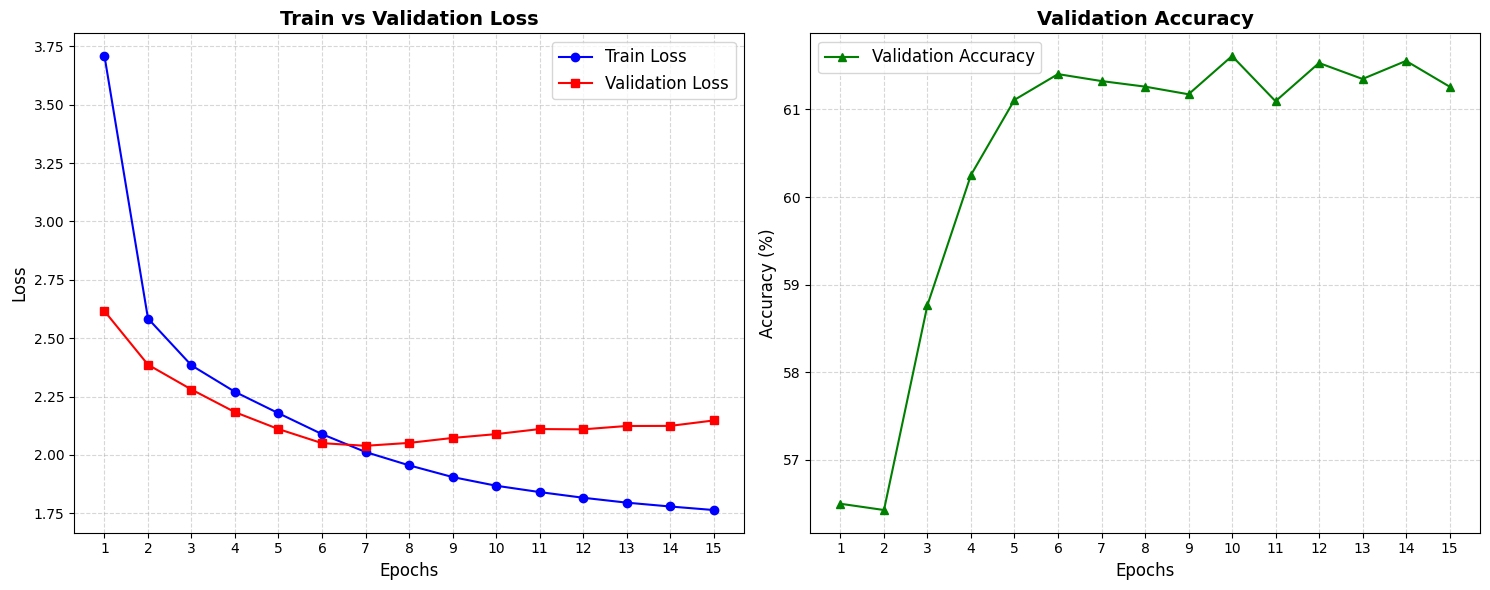

In [10]:
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(15, 6))

# 1. Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, 'b-', label='Train Loss', marker='o')
plt.plot(epochs_range, val_losses, 'r-', label='Validation Loss', marker='s')
plt.title('Train vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(epochs_range)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# 2. Biểu đồ Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_accuracies, 'g-', label='Validation Accuracy', marker='^')
plt.title('Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(epochs_range)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Bước 9: Trình diễn Khả năng Thực tế (Inference Demo)
Hàm `demo_baseline1` đố AI một bức ảnh bất kỳ từ tập Validation.
- Hàm này đã được tối ưu siêu tốc: Gọi mô hình đúng 1 lần duy nhất, tắt mớm bài (`teacher_forcing_ratio=0.0`). Cấu trúc Auto-regressive ngầm trong Model sẽ tự động nhả ra các từ cho tới khi gặp thẻ dừng `<eos>`.
- Hình ảnh, câu hỏi, câu GT (Đáp án chuẩn màu đỏ/xanh) và đáp án do AI sinh ra sẽ được hiển thị trên cùng một hình để chúng ta dễ dàng so sánh kết quả.

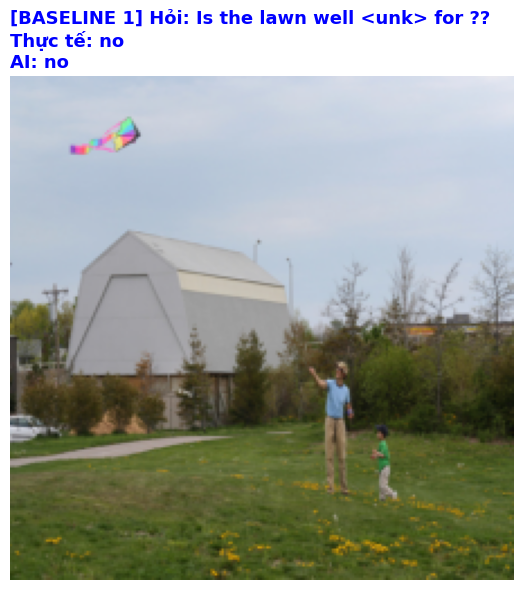

In [15]:
def demo_baseline1(model, dataset, vocab, index=None, max_len=5):
    model.eval()
    if index is None:
        index = random.randint(0, len(dataset) - 1)

    img_tensor, q_tensor, ans_tensor = dataset[index]
    img_input = img_tensor.unsqueeze(0).to(device)
    q_input = q_tensor.unsqueeze(0).to(device)

    def get_word(idx):
        try: return vocab.lookup_token(idx)
        except: return '<unk>'

    with torch.no_grad():
        # Gọi mô hình TỰ ĐỘNG SINH trong 1 lần duy nhất (ResNet18 chỉ chạy 1 lần - Rất nhanh!)
        logits = model(img_input, q_input, answer_input=None, max_gen_len=max_len, sos_idx=vocab['<sos>'], teacher_forcing_ratio=0.0)

        # Trích xuất các token có xác suất cao nhất
        pred_indices = logits.argmax(dim=-1).squeeze(0).tolist()

        pred_words = []
        for idx in pred_indices:
            if idx == vocab['<eos>']: break
            pred_words.append(get_word(idx))

        pred_sentence = " ".join(pred_words)
        if not pred_sentence.strip(): pred_sentence = "<rỗng>"

    # Xử lý text để in ra
    q_words = [get_word(idx) for idx in q_tensor.tolist()]
    q_text = " ".join([w for w in q_words if w not in ['<pad>', '<sos>', '<eos>']])

    ans_words = [get_word(idx) for idx in ans_tensor.tolist()]
    true_ans = " ".join([w for w in ans_words if w not in ['<pad>', '<sos>', '<eos>']])

    # Khôi phục ảnh
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_np = np.clip((np.array([0.229, 0.224, 0.225]) * img_np + np.array([0.485, 0.456, 0.406])), 0, 1)

    plt.figure(figsize=(6, 6))
    plt.imshow(img_np)
    color = 'blue' if pred_sentence == true_ans else 'red'
    plt.title(f"[BASELINE 1] Hỏi: {q_text}?\nThực tế: {true_ans}\nAI: {pred_sentence}",
              fontsize=13, color=color, fontweight='bold', loc='left')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Gọi thử hàm Demo mới
demo_baseline1(model, val_loader.dataset, vocab)